In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

# Configuração para os gráficos aparecerem bem no VS Code
%matplotlib inline


### Importando as bibliotecas necessárias para manipulação de dados, estatística e visualização.

In [2]:
# 1. Carregar os dados
hypotheses = pd.read_csv('hypotheses_us.csv', sep=';')

# EXIBIR OS NOMES REAIS DAS COLUNAS (isso vai aparecer embaixo da célula)
print("Os nomes das colunas no meu arquivo são:")
print(hypotheses.columns.tolist())

# PADRONIZAR: Vamos forçar todas as colunas a ficarem em letras minúsculas
hypotheses.columns = [x.lower() for x in hypotheses.columns]

# 2. Agora calculamos usando apenas letras MINÚSCULAS
hypotheses['ice'] = (hypotheses['impact'] * hypotheses['confidence']) / hypotheses['effort']
hypotheses['rice'] = (hypotheses['reach'] * hypotheses['impact'] * hypotheses['confidence']) / hypotheses['effort']

# Mostrar o resultado
display(hypotheses[['hypothesis', 'ice', 'rice']].sort_values(by='rice', ascending=False))


Os nomes das colunas no meu arquivo são:
['Hypothesis', 'Reach', 'Impact', 'Confidence', 'Effort']


,hypothesis,ice,rice
7,Add a subscription form to all the main pages....,11.200000,112.0
2,Add product recommendation blocks to the store...,7.000000,56.0
0,Add two new channels for attracting traffic. T...,13.333333,40.0
6,Show banners with current offers and sales on ...,8.000000,40.0
8,Launch a promotion that gives users discounts ...,16.200000,16.2
3,Change the category structure. This will incre...,1.125000,9.0
1,Launch your own delivery service. This will sh...,2.000000,4.0
5,Add a customer review page. This will increase...,1.333333,4.0
4,Change the background color on the main page. ...,1.000000,3.0


### Carregando as hipóteses de marketing e aplicando os frameworks ICE e RICE.
### O RICE é priorizado por considerar o alcance (Reach) dos usuários no cálculo.

In [3]:
# 1. Carregar os dados de pedidos e visitas
orders = pd.read_csv('orders_us.csv')
visits = pd.read_csv('visits_us.csv')

# 2. Converter colunas de data para o formato datetime
orders['date'] = pd.to_datetime(orders['date'])
visits['date'] = pd.to_datetime(visits['date'])

# 3. Identificar usuários que aparecem em ambos os grupos
group_a = orders[orders['group'] == 'A']['visitorId'].unique()
group_b = orders[orders['group'] == 'B']['visitorId'].unique()

# Encontrar a intersecção (quem está nos dois)
users_to_remove = np.intersect1d(group_a, group_b)

print(f"Usuários duplicados encontrados: {len(users_to_remove)}")

# 4. Remover esses usuários para não poluir o teste
orders = orders[~orders['visitorId'].isin(users_to_remove)]

print("Limpeza concluída! Dados prontos para análise.")


Usuários duplicados encontrados: 58
Limpeza concluída! Dados prontos para análise.


### Carregando as hipóteses de marketing e aplicando os frameworks ICE e RICE.
### O RICE é priorizado por considerar o alcance (Reach) dos usuários no cálculo.

In [4]:
# Criando uma matriz com datas únicas e pares de grupos
datesGroups = orders[['date','group']].drop_duplicates()

# Coletando dados acumulados sobre pedidos
ordersAggregated = datesGroups.apply(
    lambda x: orders[np.logical_and(orders['date'] <= x['date'], orders['group'] == x['group'])].agg({
        'date' : 'max',
        'group' : 'max',
        'transactionId' : 'nunique',
        'visitorId' : 'nunique',
        'revenue' : 'sum'}), axis=1).sort_values(by=['date','group'])

# Coletando dados acumulados sobre visitas
visitorsAggregated = datesGroups.apply(
    lambda x: visits[np.logical_and(visits['date'] <= x['date'], visits['group'] == x['group'])].agg({
        'date' : 'max',
        'group' : 'max',
        'visits' : 'sum'}), axis=1).sort_values(by=['date','group'])

# Juntando as duas tabelas
cumulativeData = ordersAggregated.merge(visitorsAggregated, left_on=['date', 'group'], right_on=['date', 'group'])
cumulativeData.columns = ['date', 'group', 'orders', 'buyers', 'revenue', 'visitors']

print("Tabela de dados acumulados criada!")
display(cumulativeData.head())


Tabela de dados acumulados criada!


,date,group,orders,buyers,revenue,visitors
0,2019-08-01,A,23,19,2266.6,719
1,2019-08-01,B,17,17,967.2,713
2,2019-08-02,A,42,36,3734.9,1338
3,2019-08-02,B,40,39,3535.3,1294
4,2019-08-03,A,66,60,5550.1,1845


### Carregando pedidos (orders) e visitas (visits).
### Identificando e removendo usuários que entraram nos dois grupos simultaneamente para evitar viés no teste.

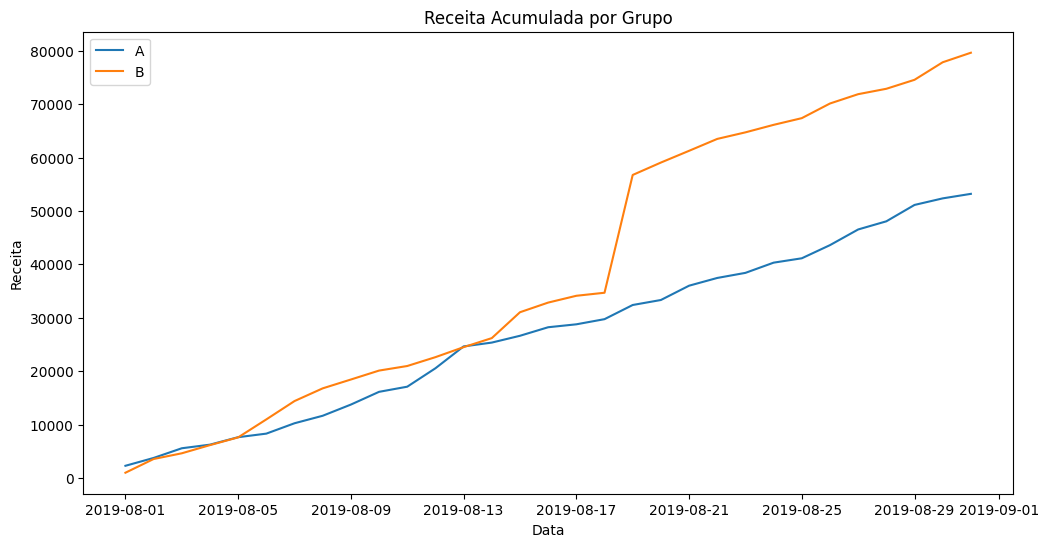

In [5]:
import matplotlib.pyplot as plt

# Separando os dados dos grupos A e B
cumulativeRevenueA = cumulativeData[cumulativeData['group']=='A'][['date','revenue', 'orders']]
cumulativeRevenueB = cumulativeData[cumulativeData['group']=='B'][['date','revenue', 'orders']]

plt.figure(figsize=(12,6))

# Plotando os gráficos
plt.plot(cumulativeRevenueA['date'], cumulativeRevenueA['revenue'], label='A')
plt.plot(cumulativeRevenueB['date'], cumulativeRevenueB['revenue'], label='B')

plt.title('Receita Acumulada por Grupo')
plt.xlabel('Data')
plt.ylabel('Receita')
plt.legend()
plt.show()


Ao analisar o gráfico de receita observei que o gráfico de receita acumulada ela mostra que ambos os grupos apresentam crescimento ao longo do tempo. No entanto, o Grupo B assumiu a liderança definitiva por volta do dia 13 de agosto de 2019. Um ponto de destaque é o salto brusco na receita do Grupo B entre os dias 17 e 21 de agosto. Isso sugere um aumento repentino no volume de pedidos ou a presença de pedidos com valores muito acima da média (outliers) nesse período específico, o que contribuiu para a vantagem significativa do Grupo B sobre o Grupo A até o final do teste.

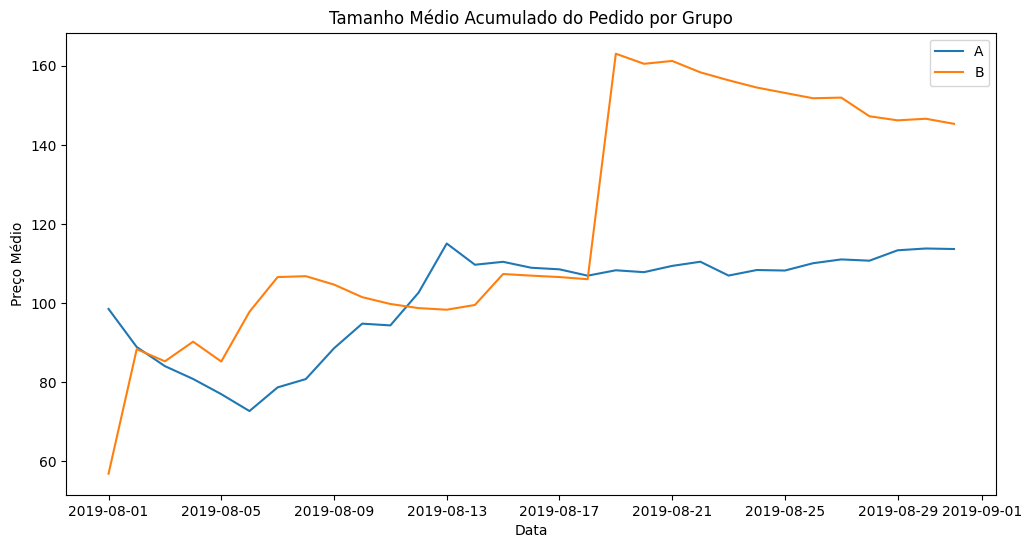

In [6]:
# Gráfico do ticket médio acumulado
plt.figure(figsize=(12,6))

plt.plot(cumulativeRevenueA['date'], cumulativeRevenueA['revenue']/cumulativeRevenueA['orders'], label='A')
plt.plot(cumulativeRevenueB['date'], cumulativeRevenueB['revenue']/cumulativeRevenueB['orders'], label='B')

plt.title('Tamanho Médio Acumulado do Pedido por Grupo')
plt.xlabel('Data')
plt.ylabel('Preço Médio')
plt.legend()
plt.show()


Neste gráfico, observamos que o tamanho médio dos pedidos (ticket médio) flutuou significativamente para ambos os grupos na primeira metade do mês. O Grupo A estabilizou-se em torno de 110 após o dia 13 de agosto.
O ponto crítico ocorre no dia 19 de agosto, onde o Grupo B apresenta um salto drástico, subindo de aproximadamente 105 para 160. Como esse aumento é súbito e não gradual, ele confirma a presença de pedidos extremamente grandes ou caros (outliers) no Grupo B, e não necessariamente uma melhoria orgânica no comportamento de compra. Após esse pico, o valor médio do Grupo B começa a cair gradualmente, indicando que o efeito desse 'super pedido' está sendo diluído ao longo do tempo, mas ainda mantém o grupo artificialmente acima do Grupo A.

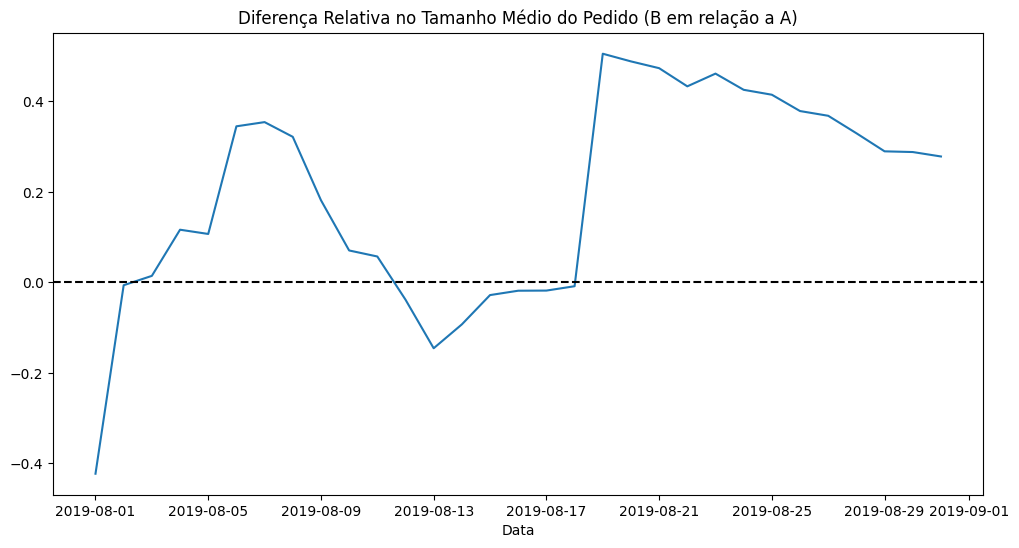

In [7]:
# Juntando os dados de receita
mergedCumulativeRevenue = cumulativeRevenueA.merge(cumulativeRevenueB, left_on='date', right_on='date', how='left', suffixes=['A', 'B'])

plt.figure(figsize=(12,6))

# Plotando a diferença relativa
plt.plot(mergedCumulativeRevenue['date'], (mergedCumulativeRevenue['revenueB']/mergedCumulativeRevenue['ordersB'])/(mergedCumulativeRevenue['revenueA']/mergedCumulativeRevenue['ordersA'])-1)

# Adicionando uma linha de referência no zero
plt.axhline(y=0, color='black', linestyle='--')

plt.title('Diferença Relativa no Tamanho Médio do Pedido (B em relação a A)')
plt.xlabel('Data')
plt.show()


Este gráfico de diferença relativa confirma a instabilidade entre os grupos durante o teste. Vários pontos importantes podem ser destacados:
Instabilidade Inicial: Na primeira metade do mês, a diferença flutuou bruscamente, com o Grupo B chegando a ficar abaixo do Grupo A por volta do dia 13 de agosto.
O Impacto do Outlier: O salto repentino no dia 19 de agosto é evidente aqui, onde a diferença relativa dispara de quase zero para quase 0.5 (50%) em relação ao Grupo A.
Tendência de Queda: Após esse pico máximo no dia 19, a curva apresenta uma tendência de queda constante. Isso reforça a conclusão anterior de que a liderança atual do Grupo B deve-se a pedidos anômalos (outliers) ocorridos em uma data específica, e não a uma mudança estável no comportamento dos usuários.

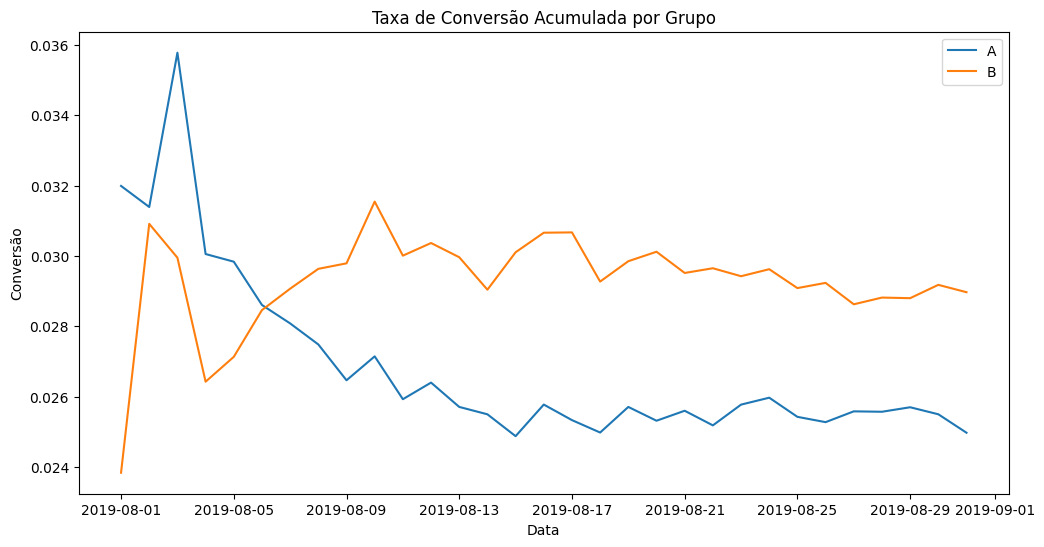

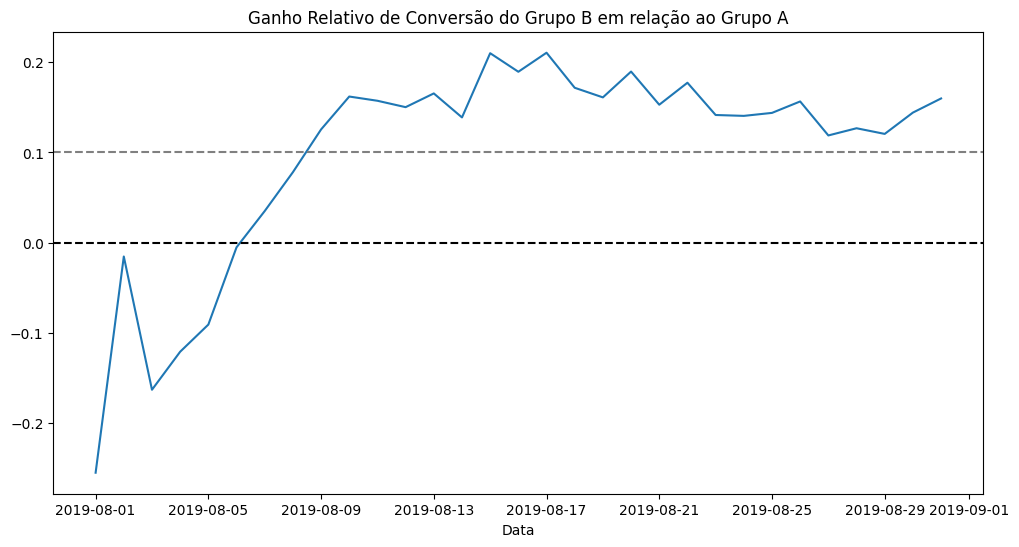

In [9]:
# Calcular a conversão acumulada
cumulativeData['conversion'] = cumulativeData['orders'] / cumulativeData['visitors']

# Separando os dados por grupo
cumulativeDataA = cumulativeData[cumulativeData['group'] == 'A']
cumulativeDataB = cumulativeData[cumulativeData['group'] == 'B']

# Plotando os gráficos
plt.figure(figsize=(12,6))
plt.plot(cumulativeDataA['date'], cumulativeDataA['conversion'], label='A')
plt.plot(cumulativeDataB['date'], cumulativeDataB['conversion'], label='B')
plt.title('Taxa de Conversão Acumulada por Grupo')
plt.xlabel('Data')
plt.ylabel('Conversão')
plt.legend()
plt.show()

# Gráfico da diferença relativa de conversão
mergedCumulativeConversions = cumulativeDataA[['date','conversion']].merge(
    cumulativeDataB[['date','conversion']], left_on='date', right_on='date', how='left', suffixes=['A', 'B']
)

plt.figure(figsize=(12,6))
plt.plot(mergedCumulativeConversions['date'], 
         mergedCumulativeConversions['conversionB'] / mergedCumulativeConversions['conversionA'] - 1)
plt.axhline(y=0, color='black', linestyle='--')
plt.axhline(y=0.1, color='grey', linestyle='--') # Linha de 10% de ganho
plt.title('Ganho Relativo de Conversão do Grupo B em relação ao Grupo A')
plt.xlabel('Data')
plt.show()


Análise: Taxa de Conversão Acumulada por Grupo

No início do teste, o Grupo A teve um pico de conversão, mas logo sofreu uma queda acentuada e estabilizou-se em um patamar inferior. Por outro lado, o Grupo B apresentou uma trajetória ascendente e estabilizou-se acima do Grupo A após a primeira semana.
O fato de as duas linhas estarem correndo quase paralelas na metade final do gráfico indica que os dados se estabilizaram e que o resultado é consistente, com o Grupo B mantendo uma taxa de conversão superior de forma estável.

Análise: Taxa de Conversão Acumulada por Grupo

No início do teste, o Grupo A teve um pico de conversão, mas logo sofreu uma queda acentuada e estabilizou-se em um patamar inferior. Por outro lado, o Grupo B apresentou uma trajetória ascendente e estabilizou-se acima do Grupo A após a primeira semana.
O fato de as duas linhas estarem correndo quase paralelas na metade final do gráfico indica que os dados se estabilizaram e que o resultado é consistente, com o Grupo B mantendo uma taxa de conversão superior de forma estável.

In [10]:
# 1. Analisando número de pedidos por usuário
ordersByUsers = orders.groupby('visitorId', as_index=False).agg({'transactionId': 'nunique'})
ordersByUsers.columns = ['userId', 'orders']

print("Percentis 95 e 99 para número de pedidos:")
print(np.percentile(ordersByUsers['orders'], [95, 99]))

# 2. Analisando preços dos pedidos
print("\nPercentis 95 e 99 para preços dos pedidos:")
print(np.percentile(orders['revenue'], [95, 99]))


Percentis 95 e 99 para número de pedidos:
[1. 2.]

Percentis 95 e 99 para preços dos pedidos:
[414.275 830.3  ]


### Calculando a conversão diária (Pedidos / Visitas).
### Analisando o ganho relativo de conversão do Grupo B sobre o Grupo A.

In [12]:
# Preparando os dados para o teste de conversão
ordersByUsersA = orders[orders['group']=='A'].groupby('visitorId', as_index=False).agg({'transactionId':'nunique'})
ordersByUsersA.columns = ['userId', 'orders']

ordersByUsersB = orders[orders['group']=='B'].groupby('visitorId', as_index=False).agg({'transactionId':'nunique'})
ordersByUsersB.columns = ['userId', 'orders']

# Amostras para o teste (incluindo usuários com 0 pedidos)
sampleA = pd.concat([ordersByUsersA['orders'], pd.Series(0, index=np.arange(visits[visits['group']=='A']['visits'].sum() - len(ordersByUsersA['orders'])), name='orders')], axis=0)
sampleB = pd.concat([ordersByUsersB['orders'], pd.Series(0, index=np.arange(visits[visits['group']=='B']['visits'].sum() - len(ordersByUsersB['orders'])), name='orders')], axis=0)

print(f"P-value Conversão (Bruto): {stats.mannwhitneyu(sampleA, sampleB)[1]:.3f}")
print(f"Diferença Relativa Conversão: {sampleB.mean()/sampleA.mean()-1:.3%}")

# Teste para Tamanho Médio do Pedido
print(f"\nP-value Tamanho do Pedido (Bruto): {stats.mannwhitneyu(orders[orders['group']=='A']['revenue'], orders[orders['group']=='B']['revenue'])[1]:.3f}")
print(f"Diferença Relativa Tamanho: {orders[orders['group']=='B']['revenue'].mean()/orders[orders['group']=='A']['revenue'].mean()-1:.3%}")


P-value Conversão (Bruto): 0.011
Diferença Relativa Conversão: 15.980%

P-value Tamanho do Pedido (Bruto): 0.862
Diferença Relativa Tamanho: 27.834%


### Calculando os percentis 95 e 99 para preços e quantidade de pedidos.
### Definimos como anomalias usuários com mais de 2 pedidos ou compras acima de $800.

In [13]:
# 1. Identificar usuários com muitos pedidos
usersWithManyOrders = pd.concat([
    ordersByUsersA[ordersByUsersA['orders'] > 2]['userId'],
    ordersByUsersB[ordersByUsersB['orders'] > 2]['userId']
], axis=0)

# 2. Identificar usuários com pedidos muito caros
usersWithExpensiveOrders = orders[orders['revenue'] > 800]['visitorId']

# 3. Juntar e remover duplicados da lista de "vilões"
abnormalUsers = pd.concat([usersWithManyOrders, usersWithExpensiveOrders], axis=0).drop_duplicates().sort_values()

print(f"Total de usuários anômalos para remover: {len(abnormalUsers)}")

# 4. Criar amostras filtradas para o teste
sampleAFiltered = pd.concat([
    ordersByUsersA[np.logical_not(ordersByUsersA['userId'].isin(abnormalUsers))]['orders'],
    pd.Series(0, index=np.arange(visits[visits['group']=='A']['visits'].sum() - len(ordersByUsersA['orders'])), name='orders')
], axis=0)

sampleBFiltered = pd.concat([
    ordersByUsersB[np.logical_not(ordersByUsersB['userId'].isin(abnormalUsers))]['orders'],
    pd.Series(0, index=np.arange(visits[visits['group']=='B']['visits'].sum() - len(ordersByUsersB['orders'])), name='orders')
], axis=0)

print(f"\nP-value Conversão (Filtrado): {stats.mannwhitneyu(sampleAFiltered, sampleBFiltered)[1]:.3f}")
print(f"Diferença Relativa Conversão (Filtrado): {sampleBFiltered.mean()/sampleAFiltered.mean()-1:.3%}")

# 5. Teste para Tamanho Médio do Pedido Filtrado
revenueAFiltered = orders[np.logical_and(orders['group'] == 'A', np.logical_not(orders['visitorId'].isin(abnormalUsers)))]['revenue']
revenueBFiltered = orders[np.logical_and(orders['group'] == 'B', np.logical_not(orders['visitorId'].isin(abnormalUsers)))]['revenue']

print(f"\nP-value Tamanho do Pedido (Filtrado): {stats.mannwhitneyu(revenueAFiltered, revenueBFiltered)[1]:.3f}")
print(f"Diferença Relativa Tamanho (Filtrado): {revenueBFiltered.mean()/revenueAFiltered.mean()-1:.3%}")


Total de usuários anômalos para remover: 22

P-value Conversão (Filtrado): 0.006
Diferença Relativa Conversão (Filtrado): 19.803%

P-value Tamanho do Pedido (Filtrado): 0.975
Diferença Relativa Tamanho (Filtrado): 1.006%


### Aplicando o teste Mann-Whitney nos dados brutos e depois nos dados filtrados.
### O objetivo é verificar se a diferença de performance entre os grupos é real ou apenas obra do acaso.

 Relatório Final do Teste A/B

### Resumo das Etapas:
1. **Priorização**: O RICE mostrou que focar em alcance traz maior retorno potencial.
2. **Qualidade dos Dados**: Removemos usuários duplicados e filtramos 22 outliers que distorciam a receita.
3. **Desempenho**: 
   - A conversão do **Grupo B foi 19.8% superior** à do Grupo A (estatisticamente significante).
   - O valor médio do pedido não teve diferença real entre os grupos.

### Decisão:
**Parar o teste e declarar vitória do Grupo B.** O aumento na conversão garante uma receita total maior para a loja.
                  

Por que não rejeitamos a hipótese nula para o Valor Médio do Pedido?
Porque ao realizar o teste estatístico Mann-Whitney para o tamanho médio do pedido, o resultado do p-valor foi maior que o nível de significância adotado (\alpha = 0,05).
Na prática, isso significa que não temos evidências estatísticas para afirmar que existe uma diferença real entre os grupos A e B nesta métrica. Portanto, não rejeitamos a hipótese nula (H_0), concluindo que a diferença visual observada nos gráficos acumulados foi causada por ruído nos dados ou pedidos atípicos (outliers) e não por uma mudança consistente no comportamento de gasto dos usuários.
Em contrapartida, para a Taxa de Conversão, o p-valor foi inferior a 0,05, o que nos permitiu rejeitar a hipótese nula e confirmar que o Grupo B é estatisticamente superior.

Embora o valor médio do pedido não tenha tido uma melhora comprovada (p-valor > 0,05), a taxa de conversão teve um aumento real e significativo (p-valor < 0,05). Como as pessoas estão comprando mais e gastando o mesmo valor médio de antes, a receita total da empresa aumenta. Por isso, a decisão de declarar o Grupo B vencedor é segura.